# Satellite Streak Trend Analysis — HETDEX PDR1

Explores distributions and correlations in the satellite streak catalogue produced by
`HETDEX_PDR1_sats.fits`.

**Plots produced**
1. Distribution of g-band magnitudes and surface brightnesses
2. Streak PA polar histogram (on-sky)
3. g_mag and SB vs MJD
4. g_mag and SB vs time since sunset / astronomical twilight
5. g_mag and SB vs telescope azimuth (`structaz`)
6. Contamination fraction (streaks / shots) per month
7. Contamination fraction vs active satellite count (from GCAT)


## Imports and configuration

In [1]:
import os
import warnings
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy.stats import binned_statistic

from astropy.table import Table, join
from astropy.time import Time
import astropy.units as u
from astroplan import Observer

warnings.filterwarnings('ignore')

# ── paths (mirror opening notebook) ──────────────────────────────────────────
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
if not op.exists(pdr_dir):
    pdr_dir = '/home/jovyan/work/pdr1/'

STREAK_FITS   = 'HETDEX_PDR1_sats.fits'
SUNSET_CACHE  = 'sunset_cache.fits'   # persisted look-up table
GCAT_TSV      = 'gcat_satcat.tsv'     # download instructions below
PLOT_DIR      = 'figures'
os.makedirs(PLOT_DIR, exist_ok=True)

# ── HET observatory (built into astropy site registry) ───────────────────────
# lat=30.681°N  lon=255.985°E (-104.015°)  elev=2026 m
HET = Observer.at_site('HET')
HET_ALT_DEG = 55.0   # mirror fixed at 55° altitude — never changes

print(f'pdr_dir  : {pdr_dir}  (exists={op.exists(pdr_dir)})')
print(f'streak   : {STREAK_FITS}')
print(f'HET site : {HET}')

pdr_dir  : /home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/  (exists=True)
streak   : HETDEX_PDR1_sats.fits
HET site : <Observer: name='HET',
    location (lon, lat, el)=(-104.01472199999998 deg, 30.681389000000003 deg, 2025.999999999443 m),
    timezone=<UTC>>


## Load streak index and IFU-index

In [2]:
# ── streak catalogue ──────────────────────────────────────────────────────────
idx = Table.read(STREAK_FITS, hdu='INDEX')
print(f'Streak index: {len(idx)} rows')
print(f'Columns: {idx.colnames}')

# ── full IFU index (one row per IFU per shot, all observations) ───────────────
ifu_all = Table.read(op.join(pdr_dir, 'ifu-index.fits'))
print(f'\nIFU index : {len(ifu_all)} rows total')
print(f'Columns   : {ifu_all.colnames[:20]} ...')

Streak index: 533 rows
Columns: ['streak_id', 'shotid', 'i', 'n_ifu', 'n_spax', 'area_arcsec2', 'ra_cen_spax', 'dec_cen_spax', 'ra_start', 'dec_start', 'ra_end', 'dec_end', 'seg_len_arcsec', 'streak_pa', 'streak_slope', 'streak_intercept', 'exptime', 'mjd_shot', 'g_mag', 'sb_mag_arcsec2', 'mean_snr']



IFU index : 431713 rows total
Columns   : ['shotid', 'ifuslot', 'ra_cen', 'dec_cen', 'flag', 'flag_badamp', 'flag_badfib', 'flag_meteor', 'flag_satellite', 'flag_shot', 'flag_throughput', 'field', 'objid', 'date', 'obsid', 'ra_shot', 'dec_shot', 'pa', 'n_ifu', 'fwhm_virus'] ...


## Build per-shot metadata table

We need `mjd` and `structaz` per shot.  
`structaz` is the **telescope azimuth** — the mirror altitude is always 55°.
Take the mean per shotid (values should be constant within a shot).

In [3]:
# columns we need from the IFU index
meta_cols = ['shotid', 'mjd', 'structaz']
# add any other per-shot columns you have, e.g. 'exptime', 'seeing'

available = [c for c in meta_cols if c in ifu_all.colnames]
missing   = [c for c in meta_cols if c not in ifu_all.colnames]
if missing:
    print(f'WARNING: columns not found in ifu-index: {missing}')

shot_meta = ifu_all[available].group_by('shotid')
shot_summary = shot_meta.groups.aggregate(np.mean)   # one row per shotid
print(f'Unique shots in IFU index: {len(shot_summary)}')

# total observations per shot (denominator for contamination fraction)
shot_counts = ifu_all.group_by('shotid')
shot_n = Table({'shotid': shot_counts.groups.keys['shotid'],
                'n_ifu_total': shot_counts.groups.aggregate(len)['shotid']})
shot_summary = join(shot_summary, shot_n, keys='shotid')
print(f'Shot summary columns: {shot_summary.colnames}')

# ── join to streak index ──────────────────────────────────────────────────────
idx = join(idx, shot_summary, keys='shotid', join_type='left')
print(f'\nAfter join: {len(idx)} streak rows')
print(f'MJD range: {np.nanmin(idx["mjd"]):.2f} – {np.nanmax(idx["mjd"]):.2f}')

Unique shots in IFU index: 6778


Shot summary columns: ['shotid', 'mjd', 'structaz', 'n_ifu_total']

After join: 533 streak rows
MJD range: 57834.27 – 60522.17


## Sunset / astronomical twilight times

Computed once per unique observing **night** (not per row) and cached to
`sunset_cache.fits` so subsequent runs just do a table look-up.

- **Sunset**: Sun at 0° horizon — geometric sunset
- **Astronomical twilight**: Sun at −18° — LEO satellites (~550 km) enter
  Earth's shadow roughly at this point, so this is the more physically
  meaningful threshold for satellite illumination.

In [4]:
# ── night key anchored to local noon at McDonald Observatory (UTC-6) ─────────
# HET is at UTC-6.  Observations run from ~local dusk to ~local dawn.
# Shifting MJD by +6h before flooring means the night key rolls over at
# local noon, so every shot on a given observing night gets the same key
# regardless of whether it falls before or after UTC midnight.
UTC_OFFSET_HR = 6.0   # McDonald Observatory: UTC-6 (CST, no DST during observing)

#idx['night_key'] = np.floor(idx['mjd'] - 0.5 + UTC_OFFSET_HR / 24.0).astype(int)
# fixed 2026-07-23

idx['night_key'] = np.floor(idx['mjd'] - 0.5 - UTC_OFFSET_HR / 24.0).astype(int)

unique_nights    = np.unique(idx['night_key'][np.isfinite(idx['mjd'])])
print(f'Unique observing nights: {len(unique_nights)}')

# ── load or compute sunset cache ─────────────────────────────────────────────
if op.exists(SUNSET_CACHE):
    print(f'Loading sunset cache from {SUNSET_CACHE} ...')
    cache_tbl = Table.read(SUNSET_CACHE)
    cached_nights = set(cache_tbl['night_key'].tolist())
    new_nights    = [n for n in unique_nights if n not in cached_nights]
    print(f'  {len(cached_nights)} nights already cached, '
          f'{len(new_nights)} new nights to compute')
else:
    cache_tbl  = None
    new_nights = list(unique_nights)
    print(f'No cache found — computing {len(new_nights)} nights')

# ── compute any missing nights ────────────────────────────────────────────────
if new_nights:
    from tqdm import tqdm
    rows = []
    for nk in tqdm(new_nights, desc='sunset calc'):
        # reference time = local noon = UTC 18:00 on that local date
        # night_key is the floor of (MJD + 6h - 0.5), so local noon MJD = nk + 0.5 - 6/24
        t_local_noon = Time(float(nk) + 0.5 - UTC_OFFSET_HR / 24.0 + 0.5,
                            format='mjd', scale='utc')
        ss  = HET.sun_set_time(t_local_noon, which='next', horizon=  0*u.deg)
        twi = HET.sun_set_time(t_local_noon, which='next', horizon=-18*u.deg)
        rows.append({'night_key':    int(nk),
                     'sunset_mjd':   float(ss.mjd),
                     'twilight_mjd': float(twi.mjd)})

    new_tbl = Table(rows)

    if cache_tbl is not None:
        from astropy.table import vstack
        cache_tbl = vstack([cache_tbl, new_tbl])
    else:
        cache_tbl = new_tbl

    cache_tbl.sort('night_key')
    cache_tbl.write(SUNSET_CACHE, overwrite=True)
    print(f'Saved {len(cache_tbl)} nights to {SUNSET_CACHE}')

# ── join cache to streak index ────────────────────────────────────────────────
idx = join(idx, cache_tbl, keys='night_key', join_type='left')

idx['dt_sunset_hr']   = (idx['mjd'] - idx['sunset_mjd'])   * 24.0
idx['dt_twilight_hr'] = (idx['mjd'] - idx['twilight_mjd'])  * 24.0

# sanity check — both should be >= 0 for all real observations
n_neg_ss  = np.sum(idx['dt_sunset_hr']   < 0)
n_neg_twi = np.sum(idx['dt_twilight_hr'] < 0)
print(f'\ndt_sunset range   : {np.nanmin(idx["dt_sunset_hr"]):.1f} – '
      f'{np.nanmax(idx["dt_sunset_hr"]):.1f} hr  ({n_neg_ss} negative — should be 0)')
print(f'dt_twilight range : {np.nanmin(idx["dt_twilight_hr"]):.1f} – '
      f'{np.nanmax(idx["dt_twilight_hr"]):.1f} hr  ({n_neg_twi} negative — should be 0)')
if n_neg_ss > 0:
    print('  NOTE: delete sunset_cache.fits and rerun this cell to recompute with corrected night keys')

Unique observing nights: 372
Loading sunset cache from sunset_cache.fits ...
  372 nights already cached, 0 new nights to compute

dt_sunset range   : 1.0 – 12.0 hr  (0 negative — should be 0)
dt_twilight range : -0.4 – 10.5 hr  (44 negative — should be 0)


## Derived geometry

In [5]:
# airmass (constant — HET altitude fixed at 55°)
idx['airmass'] = float(1.0 / np.cos(np.deg2rad(90.0 - HET_ALT_DEG)))  # ~1.221

# delta-PA: angle between streak direction and telescope azimuth
# 0° = streak runs parallel to telescope az; 90° = streak cuts perpendicular
if 'structaz' in idx.colnames and 'streak_pa_sky' in idx.colnames:
    dpa = np.abs((idx['streak_pa_sky'] - idx['structaz'] + 90) % 180 - 90)
    idx['dpa_streak_az'] = dpa.astype(np.float32)

# datetime column for plot axes
obs_times = Time(idx['mjd'], format='mjd', scale='utc')
idx['datetime'] = obs_times.to_value('datetime64')

# convenience masks
ok_mag  = np.isfinite(idx['g_mag'])   & (idx['g_mag']  > 0) & (idx['g_mag']  < 30)
ok_sb   = np.isfinite(idx['sb_mag_arcsec2']) & (idx['sb_mag_arcsec2'] > 0)
ok_time = np.isfinite(idx['dt_sunset_hr'])
ok_az   = np.isfinite(idx['structaz']) if 'structaz' in idx.colnames else np.zeros(len(idx), bool)

print(f'Valid g_mag rows : {ok_mag.sum()} / {len(idx)}')
print(f'Valid SB rows    : {ok_sb.sum()} / {len(idx)}')
print(f'Valid time rows  : {ok_time.sum()} / {len(idx)}')

Valid g_mag rows : 533 / 533
Valid SB rows    : 533 / 533
Valid time rows  : 533 / 533


## 1 · Photometric distributions

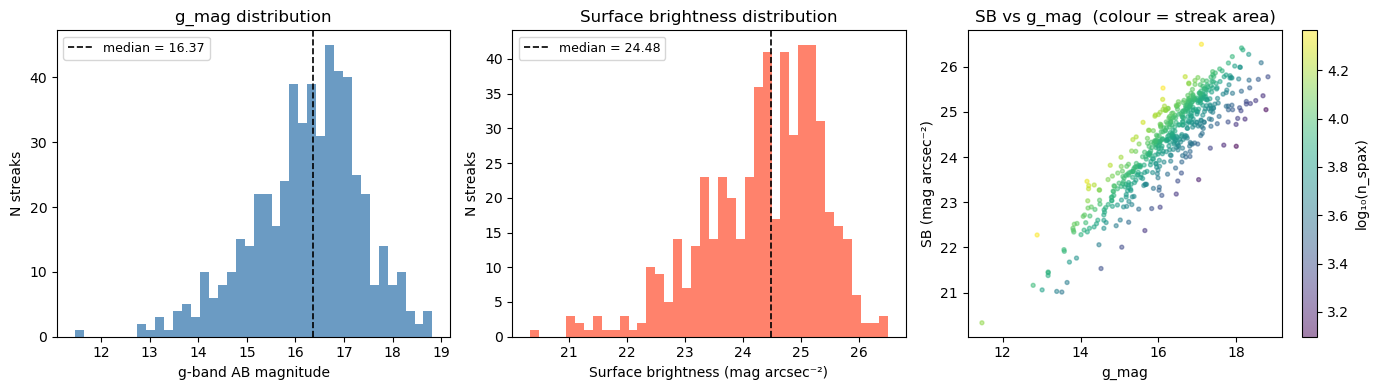

g_mag  : median=16.37  range=[11.47, 18.82]
SB     : median=24.48  range=[20.33, 26.50]


In [6]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# g_mag histogram
ax = axes[0]
gmags = idx['g_mag'][ok_mag]
ax.hist(gmags, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(np.median(gmags), color='k', lw=1.2, ls='--',
           label=f'median = {np.median(gmags):.2f}')
ax.set_xlabel('g-band AB magnitude')
ax.set_ylabel('N streaks')
ax.set_title('g_mag distribution')
ax.legend(fontsize=9)

# SB histogram
ax = axes[1]
sbs = idx['sb_mag_arcsec2'][ok_sb]
ax.hist(sbs, bins=40, color='tomato', edgecolor='none', alpha=0.8)
ax.axvline(np.median(sbs), color='k', lw=1.2, ls='--',
           label=f'median = {np.median(sbs):.2f}')
ax.set_xlabel('Surface brightness (mag arcsec⁻²)')
ax.set_ylabel('N streaks')
ax.set_title('Surface brightness distribution')
ax.legend(fontsize=9)

# g_mag vs SB scatter
ax = axes[2]
ok_both = ok_mag & ok_sb
sc = ax.scatter(idx['g_mag'][ok_both], idx['sb_mag_arcsec2'][ok_both],
                c=np.log10(idx['n_spax'][ok_both]), cmap='viridis',
                s=8, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label='log₁₀(n_spax)')
ax.set_xlabel('g_mag')
ax.set_ylabel('SB (mag arcsec⁻²)')
ax.set_title('SB vs g_mag  (colour = streak area)')

fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/01_photometric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'g_mag  : median={np.median(gmags):.2f}  range=[{gmags.min():.2f}, {gmags.max():.2f}]')
print(f'SB     : median={np.median(sbs):.2f}  range=[{sbs.min():.2f}, {sbs.max():.2f}]')

## 2 · Streak PA polar histogram

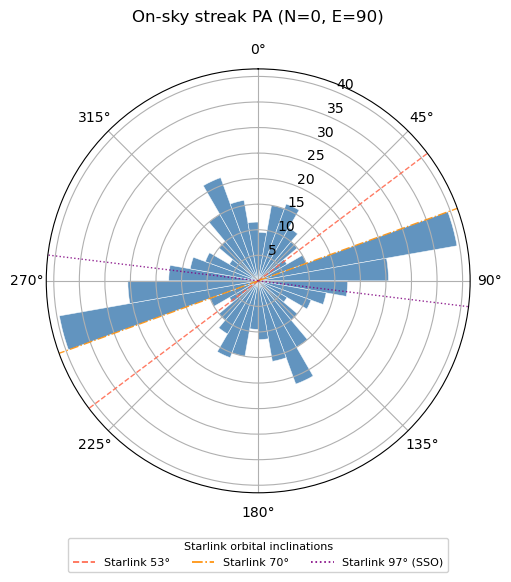

In [7]:
ok_pa = np.isfinite(idx['streak_pa'])
pas   = idx['streak_pa'][ok_pa]   # [0, 180) deg, symmetric

# mirror to [0, 360) for a full rose plot (streak has no preferred direction)
pas_full = np.concatenate([pas, pas + 180.0]) % 360.0

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection='polar')

n_bins = 36
bins   = np.linspace(0, 2 * np.pi, n_bins + 1)
hist, _ = np.histogram(np.deg2rad(pas_full), bins=bins)
width  = bins[1] - bins[0]
centres = (bins[:-1] + bins[1:]) / 2

ax.bar(centres, hist / 2, width=width, bottom=0,
       color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)

# annotate common Starlink inclinations — one line object per inclination for legend
inc_styles = [
    (53,  'Starlink 53°',   'tomato',      '--'),
    (70,  'Starlink 70°',   'darkorange',  '-.'),
    (97,  'Starlink 97° (SSO)', 'purple',  ':'),
]
legend_handles = []
import matplotlib.lines as mlines
for inc, label, color, ls in inc_styles:
    for angle in [inc, inc + 180]:
        ax.axvline(np.deg2rad(angle), color=color, lw=1.0, ls=ls, alpha=0.85)
    handle = mlines.Line2D([], [], color=color, lw=1.2, ls=ls, label=label)
    legend_handles.append(handle)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)  # clockwise = E of N
ax.set_title('On-sky streak PA (N=0, E=90)', pad=15)

# place legend outside the polar axes, below the plot
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.2), ncol=3,
          fontsize=8, framealpha=0.9,
          title='Starlink orbital inclinations', title_fontsize=8)

fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/streak_pa_polar.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · g_mag and SB vs MJD

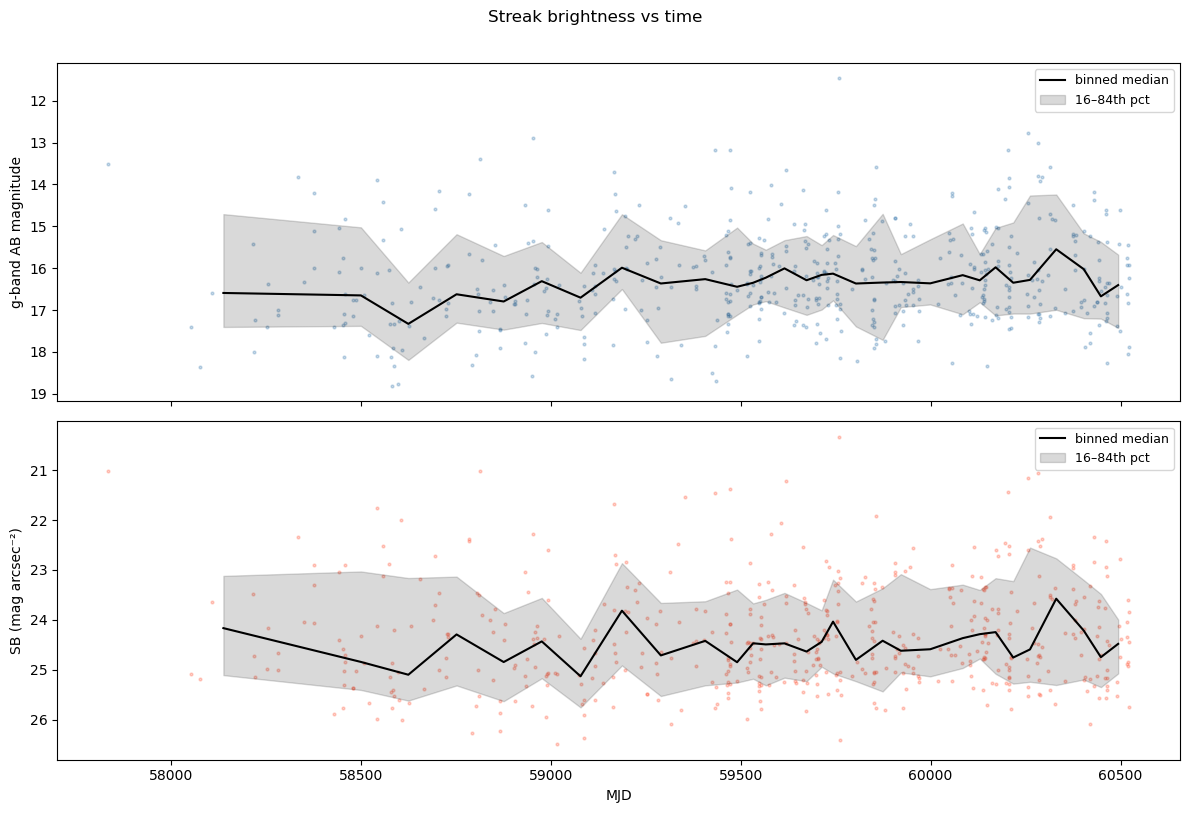

In [8]:
def running_median(x, y, n_bins=30):
    """Binned median with 16th/84th percentile envelope."""
    edges  = np.percentile(x, np.linspace(0, 100, n_bins + 1))
    edges  = np.unique(edges)
    med, _, _ = binned_statistic(x, y, statistic='median', bins=edges)
    p16, _, _ = binned_statistic(x, y, statistic=lambda v: np.percentile(v, 16), bins=edges)
    p84, _, _ = binned_statistic(x, y, statistic=lambda v: np.percentile(v, 84), bins=edges)
    ctrs = 0.5 * (edges[:-1] + edges[1:])
    return ctrs, med, p16, p84


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, col, label, color in [
    (axes[0], 'g_mag',          'g-band AB magnitude',       'steelblue'),
    (axes[1], 'sb_mag_arcsec2', 'SB (mag arcsec⁻²)',         'tomato'),
]:
    ok = ok_mag if col == 'g_mag' else ok_sb
    x  = idx['mjd'][ok]
    y  = idx[col][ok]

    ax.scatter(x, y, s=4, alpha=0.3, color=color, rasterized=True)

    xc, med, p16, p84 = running_median(x, y)
    ax.plot(xc, med, color='k', lw=1.5, label='binned median')
    ax.fill_between(xc, p16, p84, color='k', alpha=0.15, label='16–84th pct')

    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.invert_yaxis()   # brighter = smaller mag = top

# secondary x-axis in calendar year
axes[1].set_xlabel('MJD')
fig.suptitle('Streak brightness vs time', y=1.01)
fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/03_brightness_vs_mjd.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · g_mag and SB vs time since sunset / twilight

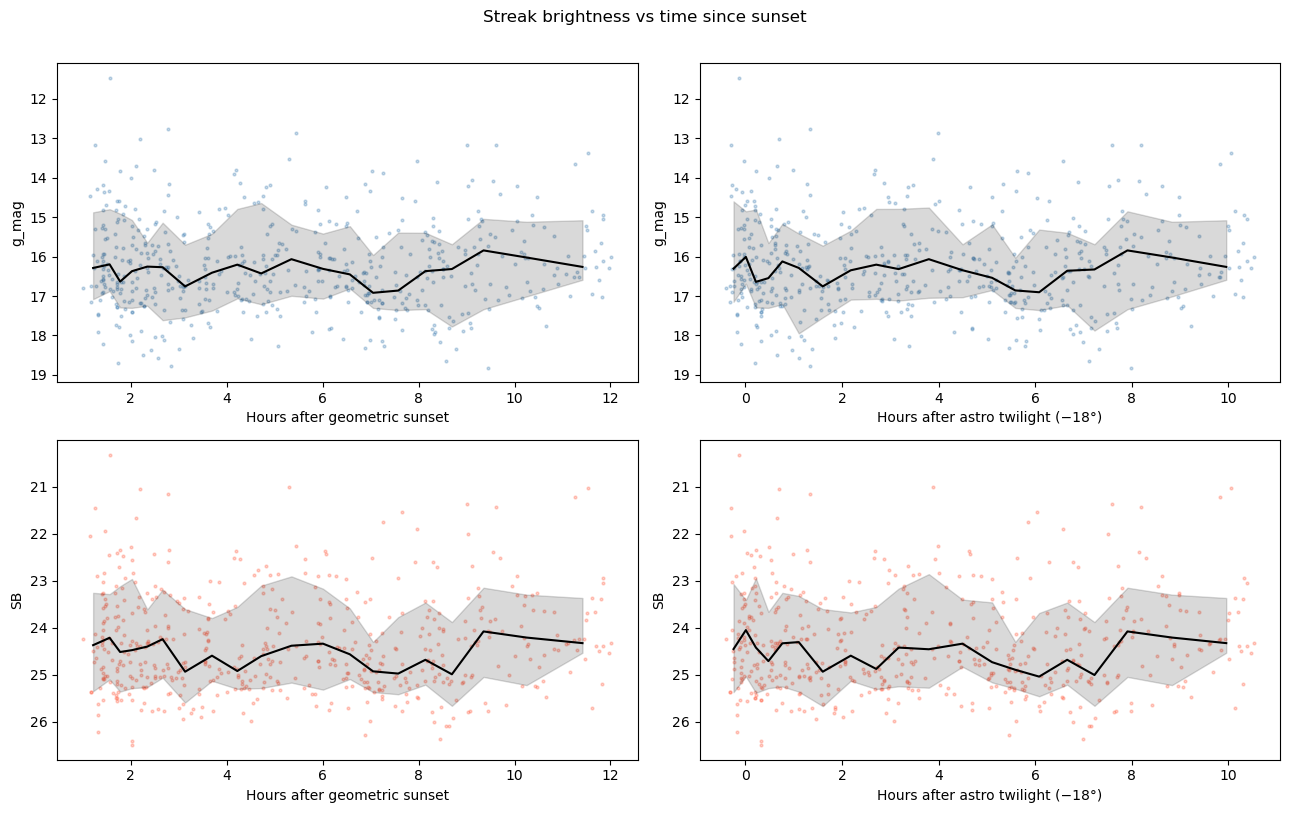

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col, col_label, row in [
    ('g_mag',          'g_mag',    0),
    ('sb_mag_arcsec2', 'SB',       1),
]:
    ok = (ok_mag if col == 'g_mag' else ok_sb) & ok_time
    y  = idx[col][ok]

    for j, (x_col, x_label) in enumerate([
        ('dt_sunset_hr',   'Hours after geometric sunset'),
        ('dt_twilight_hr', 'Hours after astro twilight (−18°)'),
    ]):
        ax = axes[row][j]
        x  = idx[x_col][ok]
        ok_x = np.isfinite(x)

        ax.scatter(x[ok_x], y[ok_x], s=4, alpha=0.3,
                   color='steelblue' if row == 0 else 'tomato', rasterized=True)

        if ok_x.sum() > 10:
            xc, med, p16, p84 = running_median(x[ok_x], y[ok_x], n_bins=20)
            ax.plot(xc, med, color='k', lw=1.5)
            ax.fill_between(xc, p16, p84, color='k', alpha=0.15)

        ax.set_xlabel(x_label)
        ax.set_ylabel(col_label)
        ax.invert_yaxis()

fig.suptitle('Streak brightness vs time since sunset', y=1.01)
fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/04_brightness_vs_sunset.png', dpi=150, bbox_inches='tight')
plt.show()

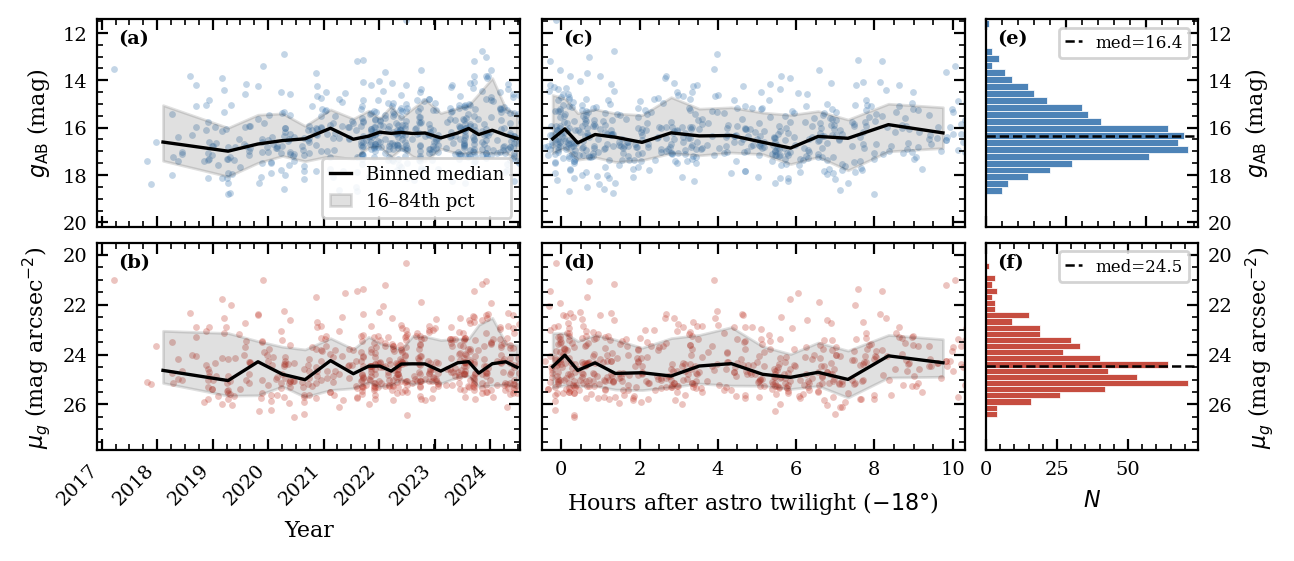

Saved gmag_trends.png


In [10]:
# ── ApJL style defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':          'serif',
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        8,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'xtick.direction':      'in',
    'ytick.direction':      'in',
    'xtick.top':             True,
    'ytick.right':           True,
    'xtick.minor.visible':   True,
    'ytick.minor.visible':   True,
    'xtick.minor.size':      2.0,
    'ytick.minor.size':      2.0,
    'xtick.major.size':      4.0,
    'ytick.major.size':      4.0,
    'legend.fontsize':       6.5,
    'legend.framealpha':     0.85,
    'legend.borderpad':      0.4,
    'lines.linewidth':       1.0,
    'figure.dpi':            200,
})

C_GMAG  = '#3A76AF'
C_SB    = '#C0392B'
C_MED   = 'k'
ALPHA_S = 0.30
S_PT    = 6

# ── Data (start from 2017) ────────────────────────────────────────────────────
MJD_2017  = 57754.0   # Jan 1 2017
ok_yr_g = ok_mag & (np.array(idx['mjd'], dtype=float) >= MJD_2017)
ok_yr_s = ok_sb  & (np.array(idx['mjd'], dtype=float) >= MJD_2017)

mjd_g = np.array(idx['mjd'][ok_yr_g], dtype=float)
mjd_s = np.array(idx['mjd'][ok_yr_s], dtype=float)
gmag  = np.array(idx['g_mag'][ok_yr_g], dtype=float)
sb    = np.array(idx['sb_mag_arcsec2'][ok_yr_s], dtype=float)

ok_t  = ok_time
ok_tg = ok_yr_g & ok_t
ok_ts = ok_yr_s & ok_t
twi_g = np.array(idx['dt_twilight_hr'][ok_tg], dtype=float)
twi_s = np.array(idx['dt_twilight_hr'][ok_ts], dtype=float)
gm_t  = np.array(idx['g_mag'][ok_tg],          dtype=float)
sb_t  = np.array(idx['sb_mag_arcsec2'][ok_ts],  dtype=float)
xmax_twi = np.nanpercentile(twi_g[np.isfinite(twi_g)], 99)

# Shared y limits — 1.5 mag padding so edge points aren't clipped
gm_ylim = (np.nanpercentile(np.concatenate([gmag, gm_t]), 99.5) + 1.5,
            np.nanpercentile(np.concatenate([gmag, gm_t]),  0.5) - 1.5)
sb_ylim = (np.nanpercentile(np.concatenate([sb,   sb_t]), 99.5) + 1.5,
            np.nanpercentile(np.concatenate([sb,   sb_t]),  0.5) - 1.5)

# ── Figure: 2 rows × 3 cols, width ratios 2:2:1 ──────────────────────────────
FIG_W, FIG_H = 7.1, 2.8
fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = fig.add_gridspec(2, 3, width_ratios=[2, 2, 1],
                        hspace=0.08, wspace=0.06)

ax_gm    = fig.add_subplot(gs[0, 0])
ax_sb    = fig.add_subplot(gs[1, 0], sharex=ax_gm)
ax_gmt   = fig.add_subplot(gs[0, 1], sharey=ax_gm)
ax_sbt   = fig.add_subplot(gs[1, 1], sharex=ax_gmt, sharey=ax_sb)
ax_ghist = fig.add_subplot(gs[0, 2], sharey=ax_gm)
ax_shist = fig.add_subplot(gs[1, 2], sharey=ax_sb)

# ── helper: scatter + binned median ──────────────────────────────────────────
def scatter_med(ax, x, y, color, n_bins=20):
    ok = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[ok], y[ok], s=S_PT, alpha=ALPHA_S, color=color,
               rasterized=True, lw=0)
    if ok.sum() > n_bins + 1:
        xc, med, p16, p84 = running_median(x[ok], y[ok], n_bins=n_bins)
        f = np.isfinite(med)
        ax.plot(xc[f], med[f], color=C_MED, lw=1.2, zorder=5, label='Binned median')
        ax.fill_between(xc[f], p16[f], p84[f], color=C_MED, alpha=0.12, zorder=4,
                        label='16–84th pct')

# ── col 0: vs MJD ────────────────────────────────────────────────────────────
scatter_med(ax_gm, mjd_g, gmag, C_GMAG)
scatter_med(ax_sb, mjd_s, sb,   C_SB)
ax_gm.set_ylim(gm_ylim)
ax_sb.set_ylim(sb_ylim)
ax_gm.set_ylabel(r'$g_{\rm AB}$ (mag)')
ax_sb.set_ylabel(r'$\mu_g$ (mag arcsec$^{-2}$)')
ax_sb.set_xlabel('Year')
plt.setp(ax_gm.get_xticklabels(), visible=False)
mjd_ticks = np.array([57754, 58119, 58484, 58849, 59215, 59580, 59945, 60310])
yr_labels = [str(y) for y in range(2017, 2025)]
ax_sb.set_xticks(mjd_ticks)
ax_sb.set_xticklabels(yr_labels, rotation=45, ha='right')
ax_gm.set_xlim(MJD_2017 - 30, mjd_ticks[-1] + 200)

# ── col 1: vs hours after astro twilight ──────────────────────────────────────
scatter_med(ax_gmt, twi_g, gm_t, C_GMAG, n_bins=15)
scatter_med(ax_sbt, twi_s, sb_t, C_SB,   n_bins=15)
for ax in [ax_gmt, ax_sbt]:
    ax.set_xlim(-0.5, xmax_twi)
ax_sbt.set_xlabel(r'Hours after astro twilight ($-18°$)')
plt.setp(ax_gmt.get_xticklabels(), visible=False)
plt.setp(ax_gmt.get_yticklabels(), visible=False)
plt.setp(ax_sbt.get_yticklabels(), visible=False)

# ── col 2: horizontal histograms, sharing y ───────────────────────────────────
def hist_h(ax, data, color):
    ok = np.isfinite(data)
    ax.hist(data[ok], bins=25, color=color, edgecolor='white',
            linewidth=0.3, alpha=0.9, orientation='horizontal')
    med = np.nanmedian(data[ok])
    ax.axhline(med, color='k', lw=0.9, ls='--', label=f'med={med:.1f}')
    ax.set_xlabel('$N$')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.legend(handlelength=1.0, loc='upper right', fontsize=6)

hist_h(ax_ghist, gmag, C_GMAG)
hist_h(ax_shist, sb,   C_SB)
for ax in [ax_ghist, ax_shist]:
    ax.yaxis.set_label_position('right')
    ax.yaxis.tick_right()
ax_ghist.set_ylabel(r'$g_{\rm AB}$ (mag)')
ax_shist.set_ylabel(r'$\mu_g$ (mag arcsec$^{-2}$)')
plt.setp(ax_ghist.get_xticklabels(), visible=False)

# ── panel labels ─────────────────────────────────────────────────────────────
for ax, lbl in zip([ax_gm, ax_sb, ax_gmt, ax_sbt, ax_ghist, ax_shist], 'abcdef'):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes,
            fontsize=7, va='top', ha='left', fontweight='bold')

ax_gm.legend(loc='lower right', handlelength=1.2)

fig.savefig(f'{PLOT_DIR}/gmag_trends.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved gmag_trends.png')

plt.rcParams.update(plt.rcParamsDefault)

In [11]:
np.max( twi_g)

np.float64(10.522473672463093)

## 5 · g_mag and SB vs telescope azimuth (`structaz`)

HET altitude is fixed at 55° — `structaz` is the only pointing variable.
Note the azimuth constraint of HET means different azimuths correspond to
different Dec strips, and thus different intersections with satellite orbital planes.

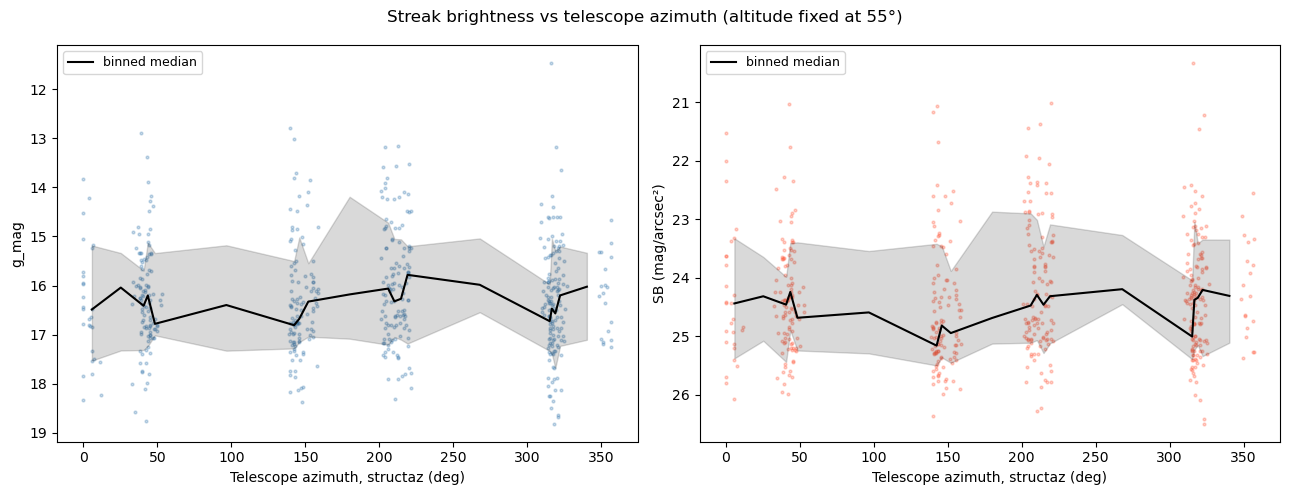

In [12]:
if 'structaz' not in idx.colnames:
    print('structaz not found in joined table — check ifu-index column name')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, col, label, color in [
        (axes[0], 'g_mag',          'g_mag',         'steelblue'),
        (axes[1], 'sb_mag_arcsec2', 'SB (mag/arcsec²)', 'tomato'),
    ]:
        ok = (ok_mag if col == 'g_mag' else ok_sb) & ok_az
        x  = idx['structaz'][ok]
        y  = idx[col][ok]

        ax.scatter(x, y, s=4, alpha=0.3, color=color, rasterized=True)

        if len(x) > 10:
            xc, med, p16, p84 = running_median(x, y, n_bins=20)
            ax.plot(xc, med, color='k', lw=1.5, label='binned median')
            ax.fill_between(xc, p16, p84, color='k', alpha=0.15)

        ax.set_xlabel('Telescope azimuth, structaz (deg)')
        ax.set_ylabel(label)
        ax.invert_yaxis()
        ax.legend(fontsize=9)

    fig.suptitle('Streak brightness vs telescope azimuth (altitude fixed at 55°)')
    fig.tight_layout()
    fig.savefig(f'{PLOT_DIR}/05_brightness_vs_az.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6 · Monthly contamination fraction

Matching the calculation in the reference notebook (RAIC_analysis):
- **Denominator**: unique shots from the ifu-index (PDR1 is already quality-filtered upstream).
- **Numerator**: shots that appear in the INDEX table (i.e. have ≥1 satellite streak).
- **Month key**: first 6 digits of `shotid` (YYYYMM) — exact, no MJD conversion needed.
- **Bi-monthly smoothing** also included, matching the green line in the reference plot.

After response_4540 > 0.08 cut: 431713 IFU rows
Unique good shots (denominator): 6778
Shots with ≥1 streak(s) (after good-shot filter): 497


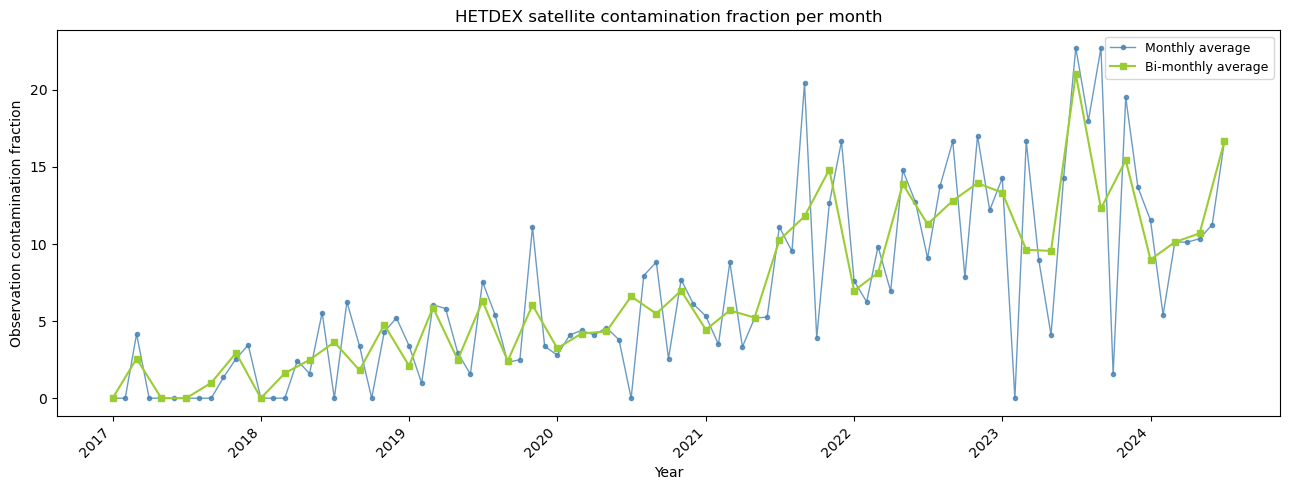


Overall contamination fraction: 7.33%
Peak monthly fraction: 22.7% in 202307


In [13]:
import datetime

# ── denominator: good-quality shots, one row per unique shotid ────────────────
# Use ifu-index directly; deduplicate on shotid.
# Apply the same throughput cut as the reference notebook: response_4540 > 0.08
# If response_4540 is not in ifu_all, we skip the cut and note it.
if 'response_4540' in ifu_all.colnames:
    ifu_good = ifu_all[ifu_all['response_4540'] > 0.08]
    print(f'After response_4540 > 0.08 cut: {len(ifu_good)} IFU rows')
else:
    ifu_good = ifu_all
    print('WARNING: response_4540 not found — no throughput cut applied (fractions may be lower)')

_, uniq_idx  = np.unique(ifu_good['shotid'], return_index=True)
shots_uniq   = ifu_good[uniq_idx]   # one row per unique good shot
print(f'Unique good shots (denominator): {len(shots_uniq)}')

# ── month key from shotid (YYYYMM) — same as old notebook ────────────────────
# shotid format: YYYYMMDDXXX  → first 6 chars = YYYYMM
def shotid_to_month(shotid_arr):
    return np.array([int(str(int(s))[:6]) for s in shotid_arr])

shots_months = shotid_to_month(shots_uniq['shotid'])   # e.g. 201704
months_sorted = np.unique(shots_months)

# ── numerator: shots with ≥1 streak in the INDEX table ───────────────────────
# Count distinct streaks per shot to apply an optional ndet threshold.
# The old notebook used ndet > 2 (i.e. ≥3 detections per shot) as a
# reliability filter before it had the per-shot FITS output.
# With the per-shot streak FITS we trust each streak record, so we use
# ≥1 streak per shot but expose the threshold as a parameter.
NSTREAK_MIN = 1   # set to 1 to match a 'any streak' definition
                  # (old code used ndet>2 on IFU-level detections, not shot-level)

streaks_per_shot = {}
for sid in idx['shotid']:
    streaks_per_shot[int(sid)] = streaks_per_shot.get(int(sid), 0) + 1

sat_shotids = np.array([sid for sid, n in streaks_per_shot.items() if n >= NSTREAK_MIN])
# keep only sat shots that are also in the good-shot denominator
sat_shotids = sat_shotids[np.isin(sat_shotids, shots_uniq['shotid'])]
sat_months  = shotid_to_month(sat_shotids)
print(f'Shots with ≥{NSTREAK_MIN} streak(s) (after good-shot filter): {len(sat_shotids)}')

# ── monthly counts ────────────────────────────────────────────────────────────
n_total_monthly  = np.array([np.sum(shots_months == m) for m in months_sorted])
n_streak_monthly = np.array([np.sum(sat_months   == m) for m in months_sorted])
fraction_monthly = n_streak_monthly / np.maximum(n_total_monthly, 1)

# bi-monthly smoothing (matching the green line in the reference plot)
monthbin = 2
i_range  = np.arange(0, len(months_sorted), monthbin)
bimonth_centres  = []
fraction_bimonth = []
for i in i_range:
    if i < len(months_sorted) - monthbin:
        sel_m = (shots_months >= months_sorted[i]) & (shots_months < months_sorted[i + monthbin])
        sel_s = (sat_months   >= months_sorted[i]) & (sat_months   < months_sorted[i + monthbin])
    else:
        sel_m = shots_months >= months_sorted[-1]
        sel_s = sat_months   >= months_sorted[-1]
    n_m = np.sum(sel_m)
    n_s = np.sum(sel_s)
    bimonth_centres.append(months_sorted[i])
    fraction_bimonth.append(n_s / max(n_m, 1))

bimonth_centres  = np.array(bimonth_centres)
fraction_bimonth = np.array(fraction_bimonth)

# convert YYYYMM integer → datetime for plotting
def ym_to_dt(ym_arr):
    return np.array([datetime.datetime.strptime(str(int(m)), '%Y%m') for m in ym_arr])

month_dt   = ym_to_dt(months_sorted)
bimonth_dt = ym_to_dt(bimonth_centres)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(month_dt,   fraction_monthly * 100,  'o-', color='steelblue', ms=3, lw=1,
        label='Monthly average', alpha=0.8)
ax.plot(bimonth_dt, fraction_bimonth * 100,  's-', color='yellowgreen', ms=4, lw=1.5,
        label='Bi-monthly average')
ax.set_xlabel('Year')
ax.set_ylabel('Observation contamination fraction')
ax.set_title('HETDEX satellite contamination fraction per month')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
fig.savefig(f'{PLOT_DIR}/06_contamination_fraction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOverall contamination fraction: {len(sat_shotids)/len(shots_uniq)*100:.2f}%')
print(f'Peak monthly fraction: {fraction_monthly.max()*100:.1f}% in '
      f'{months_sorted[np.argmax(fraction_monthly)]}')

# save for combined plot
monthly = Table({'month_int': months_sorted, 'n_total': n_total_monthly,
                 'n_streak': n_streak_monthly, 'fraction': fraction_monthly,
                 'month_dt': month_dt})

## 7 · Satellite count from GCAT (Jonathan McDowell, planet4589.org)

**One-time download** (run once, then the TSV is local):
```bash
# In a terminal:
wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv
```
GCAT is CC-BY licensed: cite as `McDowell, planet4589.org/space/gcat`.

We derive **active satellites in orbit per month** by counting objects whose
`LaunchDate` ≤ month-end and whose `DeOrbitDate` is either missing (still up)
or > month-start.

In [14]:
import pandas as pd

if not op.exists(GCAT_TSV):
    print(f'{GCAT_TSV} not found.')
    print('Download with:')
    print('  wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv')
    gcat_available = False
else:
    gcat_available = True
    # The GCAT header row itself starts with '#', so comment='#' would skip it.
    # Instead: read all lines, find the one starting with '#' that contains
    # tab-separated column names, strip the '#', and use it as the header.
    with open(GCAT_TSV, 'r', encoding='utf-8', errors='replace') as f:
        raw_lines = f.readlines()

    # The column-name line is the first '#' line that contains tabs
    header_line = None
    skip_rows   = []
    for i, line in enumerate(raw_lines):
        if line.startswith('#'):
            if '\t' in line and header_line is None:
                header_line = i          # this is the column-name row
            skip_rows.append(i)
        else:
            break   # data starts here; remaining '#' lines handled below

    # collect ALL '#' line indices in the file for skiprows
    all_comment_rows = [i for i, l in enumerate(raw_lines)
                        if l.startswith('#') and i != header_line]

    # parse column names from the header line
    col_names = raw_lines[header_line].lstrip('#').rstrip('\n').split('\t')
    col_names = [c.strip() for c in col_names]

    gcat = pd.read_csv(
        GCAT_TSV, sep='\t', header=None, names=col_names,
        skiprows=all_comment_rows + [header_line],
        low_memory=False, na_values=['-', ''],
        on_bad_lines='skip',
    )
    print(f'GCAT: {len(gcat)} rows')
    print(f'Columns: {col_names}')
    # confirmed column names from GCAT header:
    # LDate = launch date, DDate = deorbit/decay date, Type = object type
    launch_col = 'LDate'
    decay_col  = 'DDate'
    type_col   = 'Type'
    for col in [launch_col, decay_col, type_col]:
        if col not in gcat.columns:
            print(f'WARNING: expected column {col!r} not found — check TSV header')
    print(f'Sample LDate values: {gcat[launch_col].dropna().head(3).tolist()}')

gcat_satcat.tsv not found.
Download with:
  wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv


In [15]:
if gcat_available:
    # GCAT dates are like '1957 Oct  4' or '2024 Mar 15 1200' — month names, not numbers.
    # Strip any trailing time component (4-digit HHMM) before parsing.
    import re

    def parse_gcat_date(s):
        """Parse GCAT date strings of the form 'YYYY Mon DD' or 'YYYY Mon DD HHMM'."""
        if pd.isna(s):
            return pd.NaT
        s = str(s).strip()
        if s in ('', '-'):
            return pd.NaT
        # remove trailing time token (4 digits) and uncertainty markers (?, ~)
        s = re.sub(r'\s+\d{4}\??\s*$', '', s)  # trailing HHMM
        s = re.sub(r'[?~]', '', s).strip()
        # normalise internal whitespace
        s = re.sub(r'\s+', ' ', s)
        for fmt in ('%Y %b %d', '%Y %b'):
            try:
                return pd.to_datetime(s, format=fmt)
            except ValueError:
                continue
        # last resort: let pandas guess
        try:
            return pd.to_datetime(s)
        except Exception:
            return pd.NaT

    gcat['launch_dt'] = gcat[launch_col].apply(parse_gcat_date)
    gcat['decay_dt']  = gcat[decay_col].apply(parse_gcat_date)

    n_parsed_launch = gcat['launch_dt'].notna().sum()
    n_parsed_decay  = gcat['decay_dt'].notna().sum()
    print(f'Parsed launch dates: {n_parsed_launch}/{len(gcat)}')
    print(f'Parsed decay  dates: {n_parsed_decay}/{len(gcat)} '
          f'({len(gcat)-n_parsed_decay} still in orbit or unknown)')

    # filter to payloads only — Type column: 'P' prefix = payload
    # (R = rocket body, D = debris, etc.)
    if type_col in gcat.columns:
        payloads = gcat[gcat[type_col].astype(str).str.startswith('P')].copy()
        print(f'Payloads only: {len(payloads)} / {len(gcat)}')
    else:
        payloads = gcat.copy()
        print('Type column not found — using all objects (results will be inflated)')

    # Starlink subset — match on Name column (PLName or Name)
    name_col = 'PLName' if 'PLName' in payloads.columns else 'Name'
    starlinks = payloads[payloads[name_col].astype(str).str.contains(
        'STARLINK', case=False, na=False)].copy()
    print(f'Starlink payloads: {len(starlinks)}')

    # build monthly active counts over the HETDEX time range
    mjd_min = np.nanmin(shots_uniq['mjd'])
    mjd_max = np.nanmax(shots_uniq['mjd'])
    t_min   = Time(mjd_min, format='mjd').to_datetime()
    t_max   = Time(mjd_max, format='mjd').to_datetime()

    import datetime
    survey_months = pd.date_range(
        start=f'{t_min.year}-{t_min.month:02d}-01',
        end=f'{t_max.year}-{t_max.month:02d}-01',
        freq='MS'
    )

    active_counts = []
    for month_start in survey_months:
        month_end = month_start + pd.offsets.MonthEnd(1)
        for df, key in [(payloads, 'n_active'), (starlinks, 'n_starlink')]:
            launched = df['launch_dt'] <= month_end
            still_up = df['decay_dt'].isna() | (df['decay_dt'] >= month_start)
            if key == 'n_active':
                row = {'month_dt': month_start.to_pydatetime(),
                       'month':    month_start.strftime('%Y-%m'),
                       'n_active': int((launched & still_up).sum())}
            else:
                row['n_starlink'] = int((launched & still_up).sum())
        active_counts.append(row)

    sat_counts = pd.DataFrame(active_counts)
    print(sat_counts.tail(10))

## 8 · Combined plot: contamination fraction vs satellite count

In [16]:
if gcat_available:
    # ── merge monthly fraction with satellite counts ──────────────────────────
    monthly_df = monthly.to_pandas()
    monthly_df['month_dt'] = pd.to_datetime(monthly_df['month_int'].astype(str), format='%Y%m')
    sat_counts['month_int'] = sat_counts['month_dt'].apply(lambda d: int(d.strftime('%Y%m')))
    merged = pd.merge(monthly_df, sat_counts, on='month_int', how='inner')

    bimonth_df = pd.DataFrame({
        'month_dt':    bimonth_dt,
        'fraction_bi': fraction_bimonth,
        'month_int':   [int(d.strftime('%Y%m')) for d in bimonth_dt]
    })
    merged_bi = pd.merge(bimonth_df, sat_counts, on='month_int', how='inner')

    # ── ApJL 1-column figure: 3.5 inches wide ────────────────────────────────
    plt.rcParams.update({
        'font.family':         'serif',
        'font.size':            8,
        'axes.labelsize':       8,
        'xtick.labelsize':      7,
        'ytick.labelsize':      7,
        'xtick.direction':     'in',
        'ytick.direction':     'in',
        'xtick.top':            True,
        'ytick.right':          True,
        'xtick.minor.visible':  True,
        'ytick.minor.visible':  True,
        'xtick.minor.size':     2.0,
        'ytick.minor.size':     2.0,
        'xtick.major.size':     4.0,
        'ytick.major.size':     4.0,
        'legend.fontsize':      6.5,
        'legend.framealpha':    0.85,
        'lines.linewidth':      1.0,
        'figure.dpi':           200,
    })

    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
    ax2 = ax1.twinx()

    # bars: monthly fraction (background)
    ax1.bar(merged['month_dt_x'], merged['fraction'],
            width=20, color='steelblue', alpha=0.35, lw=0, label='Monthly')
    # line: bi-monthly smoothed fraction
    ax1.plot(merged_bi['month_dt_x'], merged_bi['fraction_bi'],
             'o-', color='steelblue', ms=2, lw=1.2, label='Bi-monthly avg')
    ax1.set_ylabel('Contamination fraction', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue', which='both')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    # all payloads (right axis, integers)
    ax2.plot(merged['month_dt_x'], merged['n_active'],
             '-',  color='#C0392B', lw=1.5, label='All payloads (GCAT)')
    # Starlink only
    if 'n_starlink' in merged.columns:
        ax2.plot(merged['month_dt_x'], merged['n_starlink'],
                 '--', color='#E07B39', lw=1.2, label='Starlink only')
    ax2.set_ylabel('Payloads in orbit', color='#C0392B')
    ax2.tick_params(axis='y', labelcolor='#C0392B', which='both')
    ax2.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))

    ax1.set_xlabel('Year')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.tick_params(axis='x', rotation=45)

    # combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left',
               handlelength=1.2, handletextpad=0.4)

    fig.tight_layout()
    fig.savefig(f'{PLOT_DIR}/fcont_vs_nsats.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved fcont_vs_nsats.png')
    plt.rcParams.update(plt.rcParamsDefault)

else:
    print('Skipping satellite count plot — download gcat_satcat.tsv first.')

Skipping satellite count plot — download gcat_satcat.tsv first.


## Summary statistics

In [17]:
print('=== Summary ===')
print(f'Total streak records   : {len(idx)}')
print(f'Unique shots affected  : {len(sat_shotids)}')
print(f'Total good shots       : {len(shots_uniq)}')
print(f'Overall fraction       : {len(sat_shotids)/len(shots_uniq)*100:.2f}%')
print(f'Peak monthly fraction  : {fraction_monthly.max()*100:.1f}% '
      f'({months_sorted[np.argmax(fraction_monthly)]})')
print()
print(f'g_mag   median={np.nanmedian(idx["g_mag"][ok_mag]):.2f}  '
      f'std={np.nanstd(idx["g_mag"][ok_mag]):.2f}')
print(f'SB      median={np.nanmedian(idx["sb_mag_arcsec2"][ok_sb]):.2f}  '
      f'std={np.nanstd(idx["sb_mag_arcsec2"][ok_sb]):.2f}')
print()
print(f'MJD range : {np.nanmin(idx["mjd"]):.2f} – {np.nanmax(idx["mjd"]):.2f}')
print(f'structaz  : {np.nanmin(idx["structaz"]):.1f}° – '
      f'{np.nanmax(idx["structaz"]):.1f}°  '
      f'(HET altitude fixed at {HET_ALT_DEG}°)')

=== Summary ===
Total streak records   : 533
Unique shots affected  : 497
Total good shots       : 6778
Overall fraction       : 7.33%
Peak monthly fraction  : 22.7% (202307)

g_mag   median=16.37  std=1.11
SB      median=24.48  std=1.02

MJD range : 57834.27 – 60522.17
structaz  : 0.0° – 356.7°  (HET altitude fixed at 55.0°)
